# Seminário: IA na Saúde — Equidade e Vieses
## Tópico 1: Acesso e Infraestrutura (SUS vs. Saúde Suplementar)

**UFPB · Ciência de Dados e Inteligência Artificial · Computadores e Sociedade · Prof. Ed Porto**  
**Grupo:** Helena Couto dos Santos · Mariana Esthefany Xavier dos Santos · Vitória Maria da Silva  
**Apresentador(a) desta parte:** Mariana Xavier (Pessoa 1) &nbsp;|&nbsp; **Tempo:** 20 minutos, abertura do grupo inclusa

**Pergunta-guia do seminário:** quando um algoritmo de IA erra, ele erra igual para todo mundo, ou o erro pesa mais para quem já tem menos acesso?

**Estrutura do grupo:** Pessoa 1 — Acesso e Infraestrutura · Pessoa 2 — vieses técnicos (estudo de Obermeyer, LGPD) · Pessoa 3 — responsabilidade profissional do programador e condução do debate.

---

### Mapa da apresentação (mesma ordem dos slides e do roteiro em Word)

| # | Trecho | Tempo | Slides | Material neste notebook |
|---|--------|-------|--------|-------------------------|
| 0 | Abertura do grupo | 0:00–1:00 | 1–2 | guia de fala |
| 1 | Gancho e enquadramento (SUS × plano de saúde) | 1:00–2:00 | 3–6 | tabela regional |
| 2 | **Bloco 1** — Parque tecnológico de imagem | 2:00–5:30 | 7–8 | Gráfico 1 |
| 3 | **Bloco 2** — Conectividade | 5:30–9:00 | 9 | Gráfico 2 |
| 4 | **Bloco 3** — Uso efetivo de IA (+ "Dois ritmos de adoção") | 9:00–12:00 | 10–12 | Gráfico 3 |
| 5 | **Bloco 4** — A dupla desigualdade (setor + região) | 12:00–15:00 | 13 | Gráfico 4 |
| 6 | Por que essa distância persiste? | 15:00–17:00 | 14 | guia de fala |
| 7 | Síntese — o descompasso (mismatch) estrutural | 17:00–18:30 | 15 | Gráfico 5 |
| 8 | Encerramento e transição para a Pessoa 2 | 18:30–20:00 | 16–17 | guia de fala |

**Base de dados dos gráficos.** Os números vêm de três fontes, exatamente como aparecem nos slides:

- **TIC Saúde 2025** (Cetic.br/NIC.br) — pesquisa com 3.270 gestores de estabelecimentos de saúde, fev.–nov. 2025 → Gráficos 2 e 3.
- **Atlas da Radiologia no Brasil 2025** (Colégio Brasileiro de Radiologia) e **CNES/DATASUS** → tabela regional e Gráfico 1 (*estimativas de referência*).
- **Estimativa ilustrativa** com base em padrões regionais do CNES/DATASUS → Gráfico 4; **síntese própria** (ANS + blocos anteriores) → Gráfico 5.

> ⚠️ Os Gráficos 1, 4 e 5 são estimativas/sínteses e estão rotulados assim nos slides. Ao falar, use "estimativas com base no CNES/DATASUS" em vez de "dado oficial do CNES".

In [1]:
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global padronizado
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Paleta (a mesma dos slides)
COR_SUS = '#254370'
COR_PRIVADO = '#17947f'
COR_TERCEIRA = '#f65452'   # 3ª série do Gráfico 3 (Com internação)
COR_CINZA = '#78909c'


def fonte(texto, largura=150):
    # Rodapé de fonte, igual ao dos slides.
    plt.figtext(0.01, -0.02, textwrap.fill('Fonte: ' + texto, largura),
                fontsize=8, style='italic', color=COR_CINZA, va='top')


def anotar_barras_v(ax, fmt='{:.1f}', tam=10):
    for p in ax.patches:
        v = p.get_height()
        if v > 0:
            ax.annotate(fmt.format(v), (p.get_x() + p.get_width() / 2., v),
                        ha='center', va='bottom', fontsize=tam, fontweight='bold',
                        xytext=(0, 3), textcoords='offset points')


def anotar_barras_h(ax, fmt='{:.0f}%', tam=10):
    for p in ax.patches:
        v = p.get_width()
        if v > 0:
            ax.annotate(fmt.format(v), (v, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=tam, fontweight='bold',
                        xytext=(5, 0), textcoords='offset points')


def br(n):
    # Formata inteiro no padrão brasileiro (ponto como separador de milhar).
    return f'{int(n):,}'.replace(',', '.')

---
## 0 · Abertura do grupo &nbsp;`0:00–1:00` &nbsp;(slides 1–2)

**💡 Guia de fala:**
> *"Boa tarde a todos. O nosso grupo vai apresentar hoje sobre Inteligência Artificial na Saúde, com um recorte específico: **Equidade e Vieses**, comparando dois mundos que convivem no Brasil — o SUS e a Saúde Suplementar. A pergunta que guia o seminário inteiro é: quando um algoritmo de IA erra, ele erra igual para todo mundo, ou o erro pesa mais para quem já tem menos acesso?*
>
> *Dividimos a apresentação em três partes. Eu sou **[SEU NOME]** e abro falando de **Acesso e Infraestrutura** — de onde vêm os dados que alimentam esses algoritmos. Depois, **[NOME DA PESSOA 2]** mostra como a falta de dados representativos vira viés técnico, usando o estudo de Obermeyer e a LGPD. E **[NOME DA PESSOA 3]** fecha discutindo a responsabilidade do profissional que programa esses sistemas e conduz um debate com a turma. Cada parte tem cerca de 20 minutos. Vamos começar."*

> 📌 O slide 2 (**Sumário**) está em branco. Sugestão de conteúdo: as 3 partes acima ou os blocos deste notebook.

---
## 1 · Gancho e enquadramento: o sistema de saúde brasileiro &nbsp;`1:00–2:00` &nbsp;(slides 3–6)

**Por que esta etapa importa?** Toda promessa de IA depende de dado, e o Brasil tem um sistema dual: cerca de **75%** da população depende só do SUS e **25%** tem saúde suplementar, concentrada no Sul e no Sudeste. A tabela abaixo é a mesma dos slides 5–6 (Norte e Sudeste destacados), calculada a partir dos dados por UF.

In [2]:
# Usuários de SUS e de plano de saúde por UF (mesma base do roteiro em Word)
uf = pd.DataFrame([
    ('Norte', 'Acre', 880631, 835411, 45220), ('Norte', 'Amazonas', 4281209, 3606672, 674537),
    ('Norte', 'Amapá', 802837, 739433, 63404), ('Norte', 'Pará', 8664306, 7758910, 905396),
    ('Norte', 'Rondônia', 1746227, 1582695, 163532), ('Norte', 'Roraima', 716793, 685869, 30924),
    ('Norte', 'Tocantins', 1577342, 1450651, 126691),
    ('Nordeste', 'Alagoas', 3220104, 2831273, 388831), ('Nordeste', 'Bahia', 14850513, 13113191, 1737322),
    ('Nordeste', 'Ceará', 9233656, 7777055, 1456601), ('Nordeste', 'Maranhão', 7010960, 6486970, 523990),
    ('Nordeste', 'Paraíba', 4145040, 3680381, 464659), ('Nordeste', 'Pernambuco', 9539029, 8091559, 1447470),
    ('Nordeste', 'Piauí', 3375646, 2966383, 409263), ('Nordeste', 'Rio Grande do Norte', 3446071, 2816893, 629178),
    ('Nordeste', 'Sergipe', 2291077, 1952415, 338662),
    ('Sudeste', 'Espírito Santo', 4102129, 2777894, 1324235), ('Sudeste', 'Minas Gerais', 21322691, 15501080, 5821611),
    ('Sudeste', 'Rio de Janeiro', 17219679, 11664743, 5554936), ('Sudeste', 'São Paulo', 45973194, 27722357, 18250837),
    ('Sul', 'Paraná', 11824665, 8669904, 3154761), ('Sul', 'Santa Catarina', 8058441, 6351354, 1707087),
    ('Sul', 'Rio Grande do Sul', 11229915, 8569669, 2660246),
    ('Centro-Oeste', 'Distrito Federal', 2982818, 1994558, 988260), ('Centro-Oeste', 'Goiás', 7350483, 5420270, 1930213),
    ('Centro-Oeste', 'Mato Grosso', 3836399, 3155589, 680810), ('Centro-Oeste', 'Mato Grosso do Sul', 2901895, 2217703, 684192),
], columns=['Região', 'UF', 'Pop', 'SUS', 'Plano'])
PLANO_NAO_IDENTIFICADO = 20595   # beneficiários sem UF identificada (entram só no total Brasil)

ordem = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
reg = uf.groupby('Região')[['Pop', 'SUS', 'Plano']].sum().loc[ordem]
reg.loc['BRASIL'] = [reg['Pop'].sum(), reg['SUS'].sum(), reg['Plano'].sum() + PLANO_NAO_IDENTIFICADO]

reg['% SUS'] = (reg['SUS'] / reg['Pop'] * 100).round(0).astype(int)
reg['% Plano'] = (reg['Plano'] / reg['Pop'] * 100).round(0).astype(int)

# Conferência com a tabela dos slides
assert reg.loc['BRASIL', 'Pop'] == 212_583_750 and reg.loc['BRASIL', 'SUS'] == 160_420_882
assert reg.loc['BRASIL', 'Plano'] == 52_183_463
assert list(reg['% SUS']) == [89, 87, 65, 76, 75, 75] and list(reg['% Plano']) == [11, 13, 35, 24, 25, 25]

tabela = reg.copy()
for c in ['Pop', 'SUS', 'Plano']:
    tabela[c] = tabela[c].map(br)
tabela.columns = ['População total', 'Usuários do SUS', 'Usuários de plano', '% SUS', '% Plano']
print(tabela.to_string())
print('\nFonte (slides): adaptado de Atlas da Radiologia no Brasil 2025, CBR.')


def consulta_uf(nome):
    # Consulta rápida para o debate: consulta_uf('Paraíba')
    r = uf[uf['UF'].str.lower() == nome.lower()].iloc[0]
    print(f"{r['UF']} ({r['Região']}): população {br(r['Pop'])} · SUS {br(r['SUS'])} ({r['SUS']/r['Pop']:.0%}) · "
          f"plano {br(r['Plano'])} ({r['Plano']/r['Pop']:.0%})")


consulta_uf('Paraíba')

             População total Usuários do SUS Usuários de plano  % SUS  % Plano
Região                                                                        
Norte             18.669.345      16.659.641         2.009.704     89       11
Nordeste          57.112.096      49.716.120         7.395.976     87       13
Sudeste           88.617.693      57.666.074        30.951.619     65       35
Sul               31.113.021      23.590.927         7.522.094     76       24
Centro-Oeste      17.071.595      12.788.120         4.283.475     75       25
BRASIL           212.583.750     160.420.882        52.183.463     75       25

Fonte (slides): adaptado de Atlas da Radiologia no Brasil 2025, CBR.
Paraíba (Nordeste): população 4.145.040 · SUS 3.680.381 (89%) · plano 464.659 (11%)


**💡 Guia de fala:**
> *"Antes de entrar nos números, uma contextualização rápida. A IA já é usada para **prever surtos de doenças**, **personalizar tratamento** e **analisar grandes volumes de dados de saúde pública** — tem algoritmo identificando sinais de diabetes e de doença cardíaca antes dos sintomas. É uma promessa e tanto.*
>
> *Só que toda promessa de IA depende de uma coisa simples: **dado**. Um algoritmo só reconhece um padrão que já viu muitas vezes. E o Brasil tem um sistema de saúde dual: o SUS atende cerca de **75%** da população e a saúde suplementar cobre os outros **25%**, concentrados no Sul e no Sudeste. No Norte, 89% dependem só do SUS; no Sudeste, 65%.*
>
> *Então a pergunta que eu quero deixar martelando: **se a IA aprende com dado, e a infraestrutura que gera dado está concentrada de um lado só, ela está aprendendo sobre o Brasil inteiro, ou só sobre um quarto dele?**"*

---
## Bloco 1 · O Parque Tecnológico de Imagem &nbsp;`2:00–5:30` &nbsp;(slides 7–8)
### Densidade de equipamentos por 100 mil habitantes: SUS vs. Saúde Suplementar

**Por que este gráfico é fundamental?** Exames de imagem (ressonância, tomografia, mamografia) são a matéria-prima dos modelos de visão computacional. Sem o equipamento físico, não existe imagem para treinar o algoritmo.

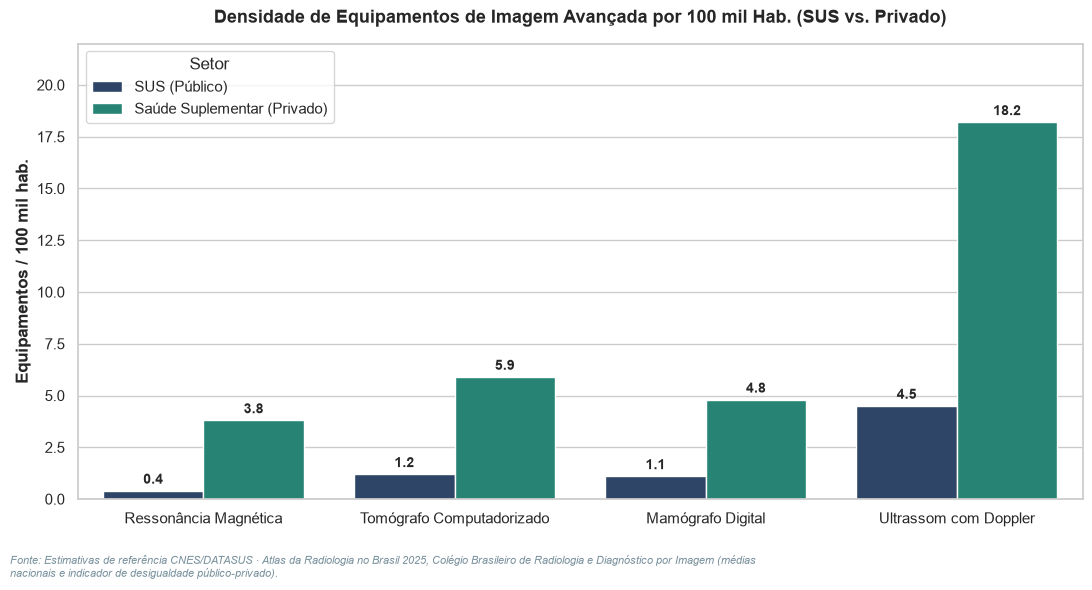

Equipamento
Ressonância Magnética        9.5
Tomógrafo Computadorizado    4.9
Mamógrafo Digital            4.4
Ultrassom com Doppler        4.0
Name: Privado ÷ SUS (vezes), dtype: float64


In [3]:
# Gráfico 1: estimativas de referência CNES/DATASUS (equipamentos por 100 mil habitantes)
dados_equip = pd.DataFrame({
    'Equipamento': ['Ressonância Magnética', 'Tomógrafo Computadorizado', 'Mamógrafo Digital', 'Ultrassom com Doppler'],
    'SUS (Público)': [0.4, 1.2, 1.1, 4.5],
    'Saúde Suplementar (Privado)': [3.8, 5.9, 4.8, 18.2]
})
df_equip = dados_equip.melt(id_vars='Equipamento', var_name='Setor', value_name='Por_100k')

plt.figure(figsize=(11, 5.5))
ax1 = sns.barplot(data=df_equip, x='Equipamento', y='Por_100k', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Densidade de Equipamentos de Imagem Avançada por 100 mil Hab. (SUS vs. Privado)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Equipamentos / 100 mil hab.', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 22)
plt.legend(title='Setor', loc='upper left')
anotar_barras_v(ax1)
fonte('Estimativas de referência CNES/DATASUS · Atlas da Radiologia no Brasil 2025, Colégio Brasileiro de Radiologia e '
      'Diagnóstico por Imagem (médias nacionais e indicador de desigualdade público-privado).')
plt.tight_layout()
plt.show()

razao = dados_equip.set_index('Equipamento')
print((razao['Saúde Suplementar (Privado)'] / razao['SUS (Público)']).round(1).rename('Privado ÷ SUS (vezes)'))

**💡 Guia de fala (3 min 30):**
> *"Vamos começar pelo começo: de onde vêm os dados que uma IA de diagnóstico por imagem precisa? De **exames de imagem** — ressonância, tomografia, mamografia. Sem o equipamento gerando esses exames, não existe imagem para treinar o algoritmo.*
>
> *Este gráfico mostra a densidade desses equipamentos a cada 100 mil habitantes. Na **ressonância**, são **0,4** no SUS contra **3,8** no privado — quase dez vezes mais. Na **tomografia**, 1,2 contra 5,9. E o padrão se repete na mamografia (1,1 contra 4,8) e no ultrassom com Doppler (4,5 contra 18,2).*
>
> *O **Atlas da Radiologia no Brasil 2025**, do Colégio Brasileiro de Radiologia, confirma o retrato: o país tem, em média, só **1,69 aparelho de ressonância por 100 mil habitantes** e, no Nordeste, apenas **1,1**. O mesmo estudo calcula o **Indicador de Desigualdade Público-Privado (IDPP)**: para exames de imagem em geral, em 2023, foi de **2,08** — quem tem plano tem mais que o dobro de acesso. Só no ultrassom, 3,74: quase quatro vezes.*
>
> *E tem um dado ainda mais chocante: no **Acre**, existem só **7 mamógrafos** para toda a rede SUS do estado — menos de 1 para cada 100 mil usuárias. Na rede privada, são 35 para cada 100 mil.*
>
> *Mas quero ser justo com o dado: entre 2014 e 2023, a densidade de exames de ressonância feitos pelo SUS **mais que dobrou** — de 6 para quase 14 por mil habitantes — e a desigualdade público-privado **caiu 30%**. A distância está diminuindo, mas ainda é enorme. E é essa distância que define **quem gera a imagem primeiro** — e, portanto, quem aparece primeiro nos dados que vão treinar a próxima geração de IA de diagnóstico."*

**Se perguntarem / se sobrar tempo (Atlas 2025):**

| Equipamento | IDPP (usuário de plano vs. exclusivo SUS) |
|---|---|
| Mamógrafo | quase 5× |
| Tomógrafo | **3,07** (menor do país: SP 1,52 · maiores: Acre 18,47 e Roraima 22,18) |
| Ressonância | pouco mais de 3× |
| Raio-X | pouco mais de 2× (o mais equilibrado) |
| Ultrassonografia | **3,74** |
| **Geral, exames de imagem (2023)** | **2,08** |

Volume de ressonâncias em 2023: privado **9.292.425** exames (181,22 por mil usuários) × SUS **2.213.807** (13,80 por mil), cobrindo cerca de 75% da população. Mamografia e tomografia: a diferença entre 2023 e 2024 diminuiu.

> ⚠️ **Não confundir as razões.** O Gráfico 1 (densidade por 100 mil hab.) dá ≈9,5× para ressonância, e o IDPP do Atlas dá "pouco mais de 3×". São indicadores diferentes, com bases diferentes. Se perguntarem, diga isso explicitamente.

---
## Bloco 2 · Conectividade além do "tem ou não tem internet" &nbsp;`5:30–9:00` &nbsp;(slide 9)
### Infraestrutura digital nos estabelecimentos de saúde (TIC Saúde 2025)

**Por que este gráfico é fundamental?** Muita solução de IA roda em nuvem: precisa de internet rápida, prontuário eletrônico e um sistema capaz de exportar/importar dados. Este é o segundo nível de infraestrutura.

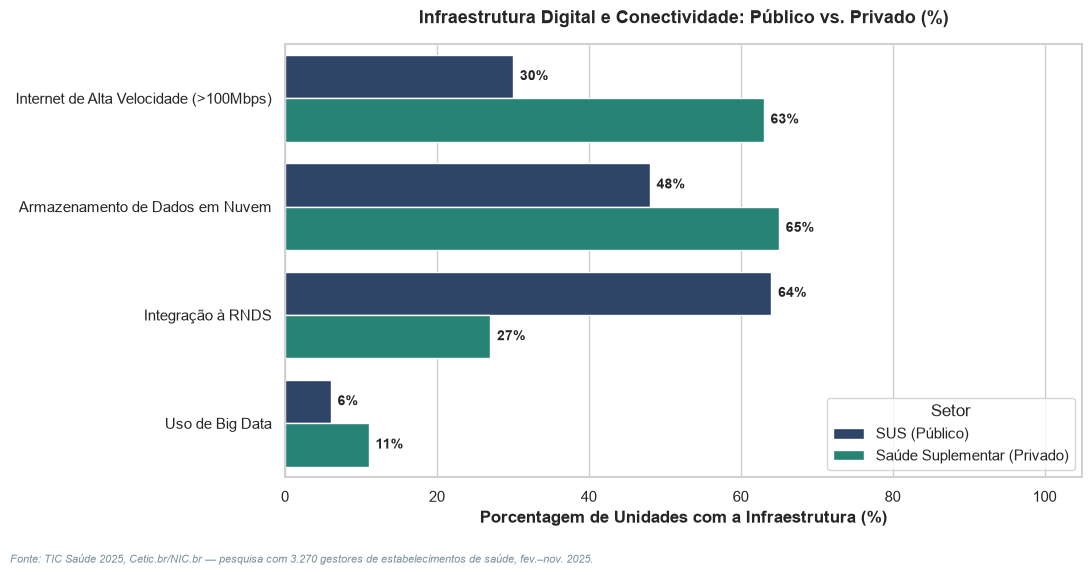

In [4]:
# Gráfico 2: TIC Saúde 2025 (Cetic.br/NIC.br), % de estabelecimentos com cada infraestrutura
dados_infra = pd.DataFrame({
    'Indicador': ['Internet de Alta Velocidade (>100Mbps)', 'Armazenamento de Dados em Nuvem',
                  'Integração à RNDS', 'Uso de Big Data'],
    'SUS (Público)': [30.0, 48.0, 64.0, 6.0],
    'Saúde Suplementar (Privado)': [63.0, 65.0, 27.0, 11.0]
})
df_infra = dados_infra.melt(id_vars='Indicador', var_name='Setor', value_name='Porcentagem')

plt.figure(figsize=(11, 5.5))
ax2 = sns.barplot(data=df_infra, y='Indicador', x='Porcentagem', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Infraestrutura Digital e Conectividade: Público vs. Privado (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de Unidades com a Infraestrutura (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 105)
plt.legend(title='Setor', loc='lower right')
anotar_barras_h(ax2)
fonte('TIC Saúde 2025, Cetic.br/NIC.br — pesquisa com 3.270 gestores de estabelecimentos de saúde, fev.–nov. 2025.')
plt.tight_layout()
plt.show()

**💡 Guia de fala (3 min 30):**
> *"Mas a IA não depende só do equipamento de imagem. Os dados mais recentes — **TIC Saúde 2025**, do Cetic.br/NIC.br, com 3.270 gestores entrevistados — trazem uma surpresa.*
>
> *A boa notícia: o acesso à internet já é praticamente universal nos estabelecimentos de saúde — **99%**, sem diferença entre público e privado — e **92%** já usam sistemas eletrônicos para registrar informações de pacientes. Então o problema está resolvido? **Não exatamente.** Ter internet não é ter internet rápida o suficiente para rodar IA. Acima de **100 Mbps** — a velocidade que sustenta sistema em nuvem e troca de imagens pesadas — estão **63%** dos estabelecimentos privados e apenas **30%** dos públicos. No armazenamento em nuvem, 65% contra 48%.*
>
> *E tem um dado revelador: **53% dos gestores de UBS nem sabem informar** a velocidade de internet contratada na própria unidade. O contrato costuma ser da secretaria municipal. O problema não é só técnico, é de gestão.*
>
> *Agora a virada, que quebra a narrativa de 'público sempre pior': na integração com a **Rede Nacional de Dados em Saúde (RNDS)**, **64%** dos estabelecimentos públicos já estão conectados, contra só **27%** dos privados. O setor público, mesmo com menos velocidade, está mais integrado a uma rede nacional de dados; o privado segue fragmentado, cada rede hospitalar com seu sistema fechado.*
>
> *O quadro que fica: o SUS não tem infraestrutura de ponta, mas tem uma política nacional de dados puxando para a interoperabilidade. O privado tem mais capacidade técnica individual, mas espalhada em silos. **Os dois lados têm gargalo, só que gargalos diferentes.**"*

*(A última barra do gráfico — Big Data, 6% × 11% — é comentada no Bloco 3.)*

**Se perguntarem:** a RNDS permite o compartilhamento seguro e padronizado de dados clínicos entre estabelecimentos públicos e privados. A troca eletrônica de informações é mais frequente no público: encaminhamentos 64% × 28%, relatórios de alta 55% × 29%, informações clínicas 53% × 25%.

---
## Bloco 3 · Uso Efetivo e Direto de Inteligência Artificial &nbsp;`9:00–12:00` &nbsp;(slides 10–12)
### Que tecnologias de IA os estabelecimentos já usam (TIC Saúde 2025)

**Por que este gráfico é fundamental?** Mostra o que está de fato rodando na prática, e não apenas o que é potencial.

> ⚠️ **Como ler o gráfico.** A base são os estabelecimentos **que já usam alguma IA** (18% do total). As três séries são **tipos de estabelecimento** (Total, Com internação até 50 leitos, SADT), **não** SUS × privado. O gráfico mostra *quais tecnologias* são usadas; a desigualdade entre setores aparece nos números falados abaixo.

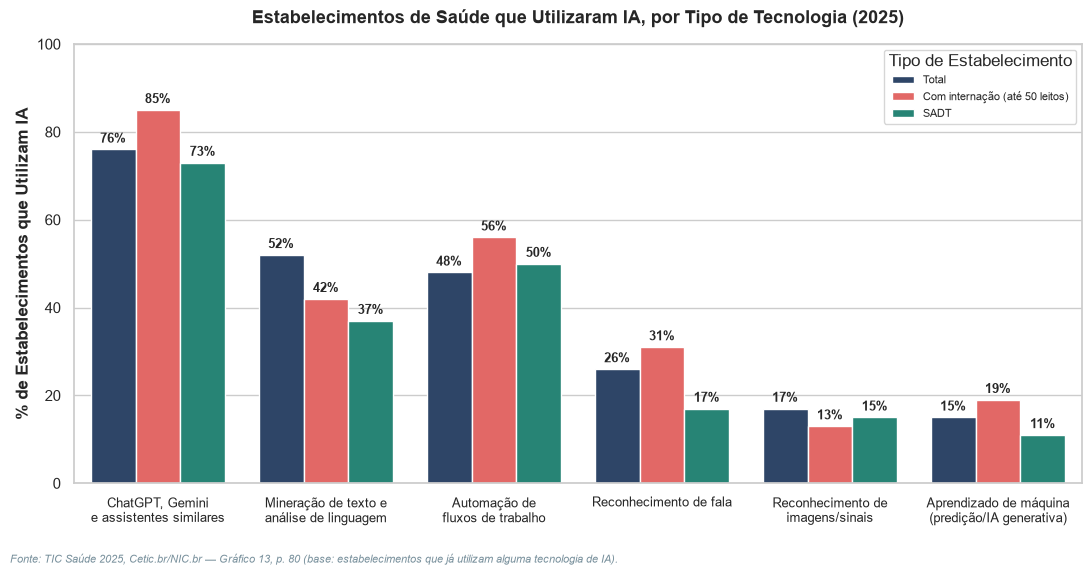

In [5]:
# Gráfico 3: TIC Saúde 2025, Gráfico 13, p. 80 (base: estabelecimentos que já utilizam alguma tecnologia de IA)
dados_ia = pd.DataFrame({
    'Tecnologia': ['ChatGPT, Gemini\ne assistentes similares', 'Mineração de texto e\nanálise de linguagem',
                   'Automação de\nfluxos de trabalho', 'Reconhecimento de fala',
                   'Reconhecimento de\nimagens/sinais', 'Aprendizado de máquina\n(predição/IA generativa)'],
    'Total': [76.0, 52.0, 48.0, 26.0, 17.0, 15.0],
    'Com internação (até 50 leitos)': [85.0, 42.0, 56.0, 31.0, 13.0, 19.0],
    'SADT': [73.0, 37.0, 50.0, 17.0, 15.0, 11.0],
})
df_ia = dados_ia.melt(id_vars='Tecnologia', var_name='Tipo de Estabelecimento', value_name='Pct')

plt.figure(figsize=(11, 5.5))
ax3 = sns.barplot(data=df_ia, x='Tecnologia', y='Pct', hue='Tipo de Estabelecimento',
                  palette=[COR_SUS, COR_TERCEIRA, COR_PRIVADO])
plt.title('Estabelecimentos de Saúde que Utilizaram IA, por Tipo de Tecnologia (2025)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('% de Estabelecimentos que Utilizam IA', fontweight='bold')
plt.xlabel('')
plt.ylim(0, 100)
plt.legend(title='Tipo de Estabelecimento', loc='upper right', fontsize=8)
anotar_barras_v(ax3, fmt='{:.0f}%', tam=9)
plt.xticks(rotation=0, ha='center', fontsize=9)
fonte('TIC Saúde 2025, Cetic.br/NIC.br — Gráfico 13, p. 80 (base: estabelecimentos que já utilizam alguma tecnologia de IA).')
plt.tight_layout()
plt.show()

**💡 Guia de fala (2 min 15 — o restante do bloco vai para "Dois ritmos", abaixo):**
> *"Com esse pano de fundo: quanto de IA está realmente rodando hoje? Segundo o TIC Saúde 2025, **18%** dos estabelecimentos já usam alguma tecnologia de IA. E não se distribui igual: sobe para **31%** entre os estabelecimentos com **mais de 50 leitos** — no Brasil, hospital grande é sinônimo de rede privada ou hospital universitário de referência — e para **29%** nos **SADT**, laboratórios e clínicas de imagem, de novo um segmento fortemente privado. Em Big Data, a diferença fica explícita: **11%** dos privados fazem esse tipo de análise, contra **6%** dos públicos.*
>
> *O que essas ferramentas fazem? Entre os que já usam IA, **76%** usam modelo de linguagem — ChatGPT, Gemini — principalmente para organizar processos clínicos e administrativos. Só **17%** envolvem reconhecimento de imagens/sinais, o uso mais próximo de auxílio a diagnóstico. É muito mais **automação de burocracia** do que IA salvando vidas, por enquanto.*
>
> *Isso cria um ciclo: quem já tem mais infraestrutura, equipamento e dado adota IA mais rápido, e cada uso gera mais dado para a próxima geração de algoritmo. **Infraestrutura vira vantagem de dado, e vantagem de dado vira vantagem de IA.**"*

**Se perguntarem:**
- Adoção também depende de governança e qualidade dos dados, capacitação profissional e integração entre sistemas, não só de infraestrutura.
- Aplicações mais comuns: apoio ao diagnóstico por imagem, análise de dados clínicos, monitoramento remoto de pacientes, automação administrativa e logística.
- Regulação: a **Resolução CFM nº 2.454/2026** normatiza o uso de IA na medicina. Os sistemas devem apoiar a prática médica, preservando a autonomia profissional; a decisão clínica final é do médico; exige-se transparência, monitoramento e proteção de dados.
- *Dado extra (não está nos slides):* na divulgação do TIC Saúde 2025, o uso de IA aparece em **25% dos estabelecimentos privados contra 11% dos públicos**. Confira na tabela original do Cetic.br antes de citar.

> ⚠️ **Não misturar:** os 31% (>50 leitos) são a *taxa de adoção* sobre todos os estabelecimentos do grupo. Os 31% da barra "Reconhecimento de fala" no gráfico são outra coisa (parcela de quem usa IA). Confirme também a legenda "Com internação (até 50 leitos)" no Gráfico 13, p. 80 do relatório.

### Slides 11–12 · Dois ritmos de adoção de IA &nbsp;`(~45 s, dentro dos 3 min do Bloco 3)`

O roteiro em Word **não tinha texto para estes slides**. A fala abaixo usa apenas o que está nos slides.

| | **SUS** | **Saúde Suplementar** |
|---|---|---|
| **Status do projeto** | 14 UTIs automatizadas planejadas em todo o país · 6 unidades de excelência modernizadas | Uma operadora já automatiza **95,1%** das respostas a autorizações de exames, consultas e internações com IA |
| **Regulador / auditoria** | ANS (abr/2026): ainda "em fase de planejamento e na busca de recursos" para ampliar o uso de IA na própria agência | ABRAMGE: de menos de 20% para **100%** das contas médicas auditadas com apoio de IA |

**💡 Guia de fala:**
> *"Vale olhar para o ritmo. No SUS, o Ministério da Saúde anunciou em novembro de 2025 a criação de uma rede de hospitais e serviços inteligentes: **14 UTIs automatizadas planejadas** e **6 unidades de excelência modernizadas**. Ou seja: **planejamento**. Do lado da saúde suplementar, já há **operação**: uma operadora automatiza 95,1% das respostas a autorizações de exames, consultas e internações, e a ABRAMGE relata que a auditoria de contas médicas com apoio de IA foi de menos de 20% para 100%. Dois ritmos: um planejando, o outro já rodando, e quem roda gera dado."*

> ⚠️ **Antes de apresentar:** (1) o slide 12 coloca a fala da ANS na coluna do SUS, mas a ANS regula a saúde suplementar. Ajuste o rótulo ou explique que é o regulador falando da própria agência. (2) A fonte de "95,1%" e da ABRAMGE não aparece nos slides; tenha-a à mão. (3) Há erros de digitação no slide ("APLIAR", "PRÓPIA").

---
## Bloco 4 · A Dupla Desigualdade (Setorial + Regional) &nbsp;`12:00–15:00` &nbsp;(slide 13)
### Leitos de UTI por 10 mil habitantes, por região

**Por que este gráfico é fundamental?** O problema não é só SUS × privado, é também geográfico: a capacidade tecnológica se concentra no eixo Sul-Sudeste. E UTI importa para IA porque gera os dados mais ricos e contínuos do paciente.

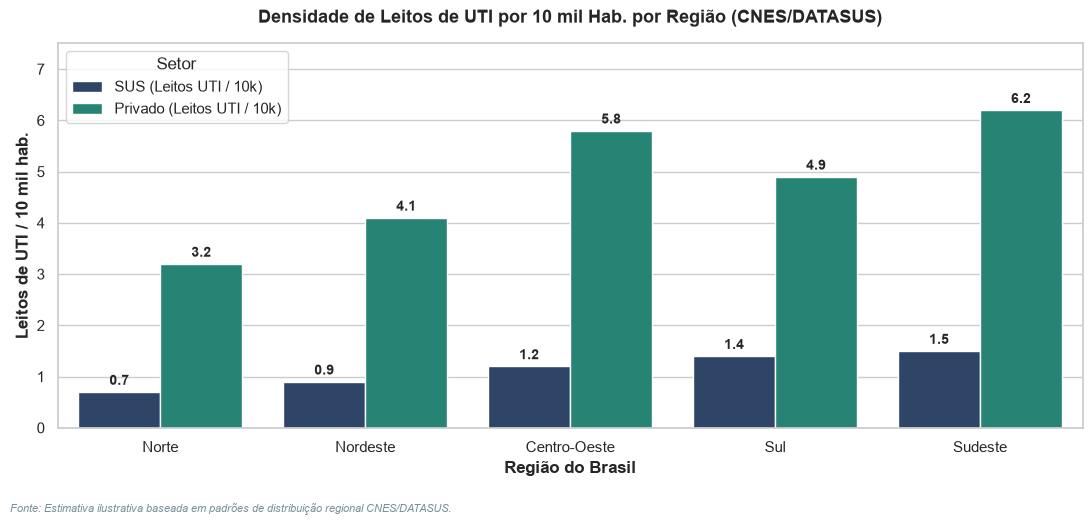

Melhor combinação (privado, Sudeste): 6.2 · pior (SUS, Norte): 0.7 · razão ≈ 8.9×


In [6]:
# Gráfico 4: estimativa ilustrativa baseada em padrões de distribuição regional CNES/DATASUS
dados_uti = pd.DataFrame({
    'Região': ['Norte', 'Nordeste', 'Centro-Oeste', 'Sul', 'Sudeste'],
    'SUS (Leitos UTI / 10k)': [0.7, 0.9, 1.2, 1.4, 1.5],
    'Privado (Leitos UTI / 10k)': [3.2, 4.1, 5.8, 4.9, 6.2]
})
df_uti = dados_uti.melt(id_vars='Região', var_name='Setor', value_name='Leitos_10k')

plt.figure(figsize=(11, 5))
ax4 = sns.barplot(data=df_uti, x='Região', y='Leitos_10k', hue='Setor', palette=[COR_SUS, COR_PRIVADO])
plt.title('Densidade de Leitos de UTI por 10 mil Hab. por Região (CNES/DATASUS)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Leitos de UTI / 10 mil hab.', fontweight='bold')
plt.xlabel('Região do Brasil', fontweight='bold')
plt.ylim(0, 7.5)
plt.legend(title='Setor', loc='upper left')
anotar_barras_v(ax4)
fonte('Estimativa ilustrativa baseada em padrões de distribuição regional CNES/DATASUS.')
plt.tight_layout()
plt.show()

melhor = dados_uti['Privado (Leitos UTI / 10k)'].max()   # Privado, Sudeste
pior = dados_uti['SUS (Leitos UTI / 10k)'].min()         # SUS, Norte
print(f'Melhor combinação (privado, Sudeste): {melhor} · pior (SUS, Norte): {pior} · razão ≈ {melhor / pior:.1f}×')

**💡 Guia de fala (3 min):**
> *"Até agora mostrei uma desigualdade: público contra privado. Mas há uma segunda camada, que se soma à primeira: a **geográfica**. O Brasil não é dividido só entre SUS e plano de saúde, mas também entre o **Sul-Sudeste e o resto do país**.*
>
> *Este gráfico mostra leitos de UTI a cada 10 mil habitantes nas cinco regiões, separando SUS e privado. Olhem o extremo: o **privado no Sudeste tem cerca de 6,2**; o **SUS no Norte tem 0,7** — uma diferença de **quase 9 vezes** entre a melhor e a pior combinação.*
>
> *Por que UTI importa para IA? Porque é nesses ambientes de alta complexidade que nascem os **dados mais ricos e contínuos** sobre o paciente — sinais vitais em tempo real, séries temporais — que alimentam os algoritmos preditivos mais sofisticados, aqueles que conseguem prever uma piora clínica horas antes.*
>
> *Temos uma **dupla concentração**: os dados de alta complexidade nascem majoritariamente no setor privado e, dentro dele, majoritariamente no eixo Sul-Sudeste. Um algoritmo treinado com esse dado aprende, essencialmente, como é o corpo — e a doença — de um paciente de UTI privada paulista. Será que ele funciona igual num paciente do SUS, no interior do Pará ou do Maranhão, com um perfil epidemiológico completamente diferente? Essa pergunta é exatamente a ponte para o próximo tópico."*

> 📌 O slide rotula o gráfico como **estimativa ilustrativa**. Ao falar "cerca de 6,2" e "0,7", deixe claro que são estimativas.

---
## Por que essa distância persiste? &nbsp;`15:00–17:00` &nbsp;(slide 14)

| Eixo | O que dizer |
|---|---|
| **Burocracia** | Aprovação em múltiplos níveis (municipal, estadual, federal) torna a adoção lenta; falta planejamento estratégico de investimento em TI |
| **Formação** | Regiões remotas têm limitações de infraestrutura **e** de profissionais capacitados: não adianta ter o equipamento sem quem opere e mantenha |
| **Resultado** | Implementação fragmentada (ex.: UBS com prontuário eletrônico decente, mas sem saber a própria velocidade de internet) |

**💡 Guia de fala:**
> *"Por que essa desigualdade persiste, mesmo com o SUS sendo, no papel, universal? Uma parte é **burocracia**: levar tecnologia ao setor público esbarra em aprovações em vários níveis — municipal, estadual, federal — e, muitas vezes, na falta de planejamento estratégico de investimento em TI. O resultado é uma **implementação fragmentada**: uma UBS com prontuário eletrônico decente, mas sem saber a própria velocidade de internet.*
>
> *A outra parte é **formação**: regiões remotas enfrentam limitações de infraestrutura e de profissionais capacitados — não adianta ter o equipamento se não tem quem opere e mantenha.*
>
> *E não percam de vista a promessa do início: a IA de verdade ajuda — prevê surtos, antecipa diabetes e doença cardíaca, otimiza triagem. **O problema nunca foi a tecnologia em si.** É que ela está sendo construída e testada majoritariamente onde já existem infraestrutura, dado e capital. Reduzir essa desigualdade não é só justiça social: é **qualidade técnica**. Um algoritmo mais representativo é um algoritmo mais seguro para todo mundo."*

---
## Bloco 5 · Síntese: o Descompasso (Mismatch) Estrutural de Dados &nbsp;`17:00–18:30` &nbsp;(slide 15)
### População dependente vs. infraestrutura e uso de IA (barra empilhada 100%)

**Por que este gráfico é fundamental?** Junta tudo em uma imagem: a demanda populacional de um lado, a infraestrutura geradora de dados do outro.

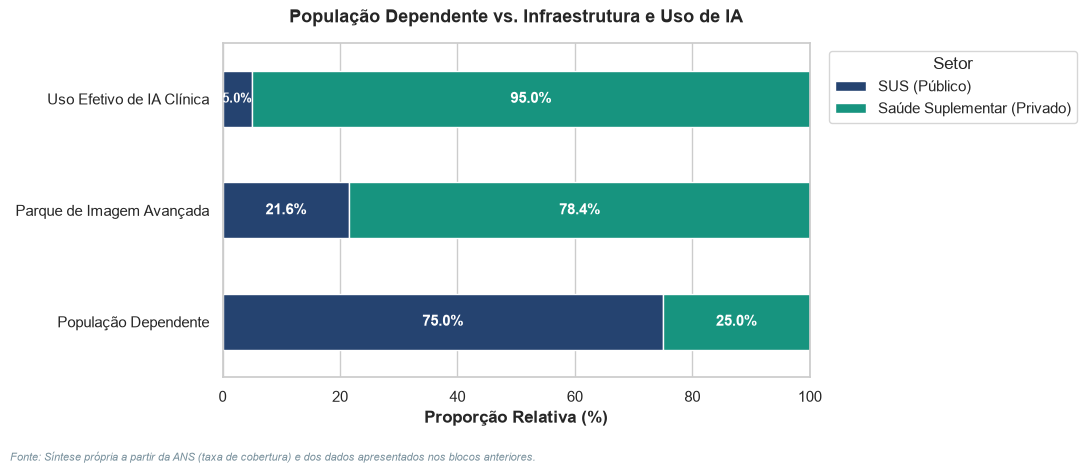

In [7]:
# Gráfico 5: síntese própria a partir da ANS (taxa de cobertura) e dos dados dos blocos anteriores
dados_mismatch = pd.DataFrame({
    'Dimensão': ['População Dependente', 'Parque de Imagem Avançada', 'Uso Efetivo de IA Clínica'],
    'SUS (Público)': [75.0, 21.6, 5.0],
    'Saúde Suplementar (Privado)': [25.0, 78.4, 95.0]
}).set_index('Dimensão')

ax5 = dados_mismatch.plot(kind='barh', stacked=True, color=[COR_SUS, COR_PRIVADO], figsize=(11, 4.5))
plt.title('População Dependente vs. Infraestrutura e Uso de IA', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Proporção Relativa (%)', fontweight='bold')
plt.ylabel('')
plt.xlim(0, 100)
plt.legend(title='Setor', bbox_to_anchor=(1.02, 1), loc='upper left')

for container in ax5.containers:
    for patch in container:
        w = patch.get_width()
        if w > 0:
            ax5.annotate(f'{w:.1f}%', (patch.get_x() + w / 2, patch.get_y() + patch.get_height() / 2),
                         ha='center', va='center', color='white', fontweight='bold', fontsize=11 if w > 10 else 9)

fonte('Síntese própria a partir da ANS (taxa de cobertura) e dos dados apresentados nos blocos anteriores.')
plt.tight_layout()
plt.show()

**💡 Guia de fala (1 min 30):**
> *"Para fechar minha parte, junto tudo num único gráfico de barra empilhada, com três proporções. Primeiro, como a população se divide entre SUS e saúde suplementar: **75% para 25%**. Segundo, como o parque de imagem avançada se divide: **21,6% no SUS contra 78,4% no privado**. Terceiro, como o uso efetivo de IA clínica se divide: **5% no SUS contra 95% no privado**.*
>
> *Reparem na inversão: a linha de baixo é quase o espelho invertido da de cima. **Setenta e cinco por cento das pessoas dependem do SUS, mas geram, proporcionalmente, uma fração pequena dos dados de imagem avançada — e uma fração ainda menor da IA clínica em uso.** Isso é o que chamo de **mismatch estrutural**: um descompasso entre onde estão as pessoas e onde estão os dados que vão treinar os algoritmos que, um dia, talvez cuidem dessas mesmas pessoas."*

> ⚠️ Os 21,6% e os 5% são síntese própria do grupo. Não dá para reproduzi-los a partir dos Gráficos 1 e 3 (a ponderação 75/25 dos equipamentos do Gráfico 1 daria 24% a 43% no SUS). Se o professor perguntar, explique o critério do grupo.

---
## Encerramento e Transição (Pessoa 1 ➔ Pessoa 2) &nbsp;`18:30–20:00` &nbsp;(slides 16–17)

**💡 Guia de fala:**
> *"Resumindo a nossa análise de Acesso e Infraestrutura, em quatro pontos:*
> 1. ***Gargalo de equipamento** — imagem avançada concentrada no privado, até dez vezes mais por habitante.*
> 2. ***Gargalo de qualidade de conexão** — só 30% da rede pública tem velocidade adequada para IA, contra 63% da privada.*
> 3. ***Uso efetivo concentrado** — apenas 18% dos estabelecimentos usam IA hoje, majoritariamente nos maiores e mais privados.*
> 4. ***A sombra dos dados** — 75% dependem do SUS, mas praticamente toda a infraestrutura e o uso clínico de IA estão do lado privado.*
>
> ***A ponte para o próximo tópico:** se quase toda a infraestrutura e os dados de treino vêm desse ecossistema privado, concentrado e relativamente homogêneo, **o que acontece quando aplicamos esses algoritmos na população geral do SUS? Que vieses aparecem quando o modelo não "conhece" essa realidade?***
>
> *Para responder, e mostrar os impactos clínicos reais desse viés algorítmico, passo a palavra para **[NOME DA PESSOA 2]**."*

---
## Apêndice A · Checklist de consistência antes de apresentar

Números que **precisam** ser ditos iguais nos slides, no roteiro e neste notebook:

| Tema | Valor correto | Onde aparece |
|---|---|---|
| População SUS × plano | 75% × 25% (160.420.882 × 52.183.463) | slide 4–5, Gancho |
| Ressonância (por 100 mil hab.) | 0,4 (SUS) × 3,8 (privado) | Gráfico 1 |
| IDPP geral, imagem, 2023 | 2,08 | slide 8 |
| Internet > 100 Mbps | 30% (público) × 63% (privado) | Gráfico 2, Encerramento |
| Nuvem · RNDS · Big Data | 48/65 · 64/27 · 6/11 (público/privado) | Gráfico 2 |
| Estabelecimentos que usam IA | 18% (31% >50 leitos · 29% SADT) | Bloco 3, Encerramento |
| Tipo de IA mais usada | 76% modelo de linguagem · 17% imagens/sinais | Gráfico 3 |
| UTI (por 10 mil hab.) | 6,2 (privado, Sudeste) × 0,7 (SUS, Norte) ≈ 9× | Gráfico 4 |
| Descompasso | 75/25 · 21,6/78,4 · 5/95 | Gráfico 5 |

## Apêndice B · Fontes e referências

**Consultadas diretamente**
- NÚCLEO DE INFORMAÇÃO E COORDENAÇÃO DO PONTO BR (NIC.br). *Pesquisa sobre o uso das tecnologias de informação e comunicação nos estabelecimentos de saúde brasileiros — TIC Saúde 2025.* São Paulo: Cetic.br/NIC.br, 2026.
- COLÉGIO BRASILEIRO DE RADIOLOGIA E DIAGNÓSTICO POR IMAGEM (CBR). *Atlas da Radiologia no Brasil 2025.* São Paulo: CBR, 2025.
- ALENCAR, C. A. C. et al. Tomografia computadorizada e ressonância magnética no Brasil: estudo epidemiológico sobre distribuição dos equipamentos, frequência de realização dos exames e comparação entre setores público e privado. *Radiologia Brasileira*, v. 57, e20230094, 2024.
- AGÊNCIA NACIONAL DE SAÚDE SUPLEMENTAR (ANS) e IBGE — população total, usuários do SUS e de plano por UF. *(Confirmar o relatório exato.)*
- CONSELHO FEDERAL DE MEDICINA (CFM). *Resolução CFM nº 2.454/2026* — uso de IA na prática médica (citada no TIC Saúde 2025).
- CNES/DATASUS — estimativas de referência de equipamentos e leitos (Gráficos 1 e 4).
- Notícias dos slides 11–12: Ministério da Saúde (rede de hospitais inteligentes, 18/11/2025); ANS (uso de IA, 15/04/2026); evento Futuro da Saúde (13/08/2025). ABRAMGE e operadora (95,1%): incluir a referência.

**Fontes secundárias citadas no relatório TIC Saúde 2025** (não consultadas diretamente)
- OCDE. Adoção de tecnologias digitais em saúde, 2023.
- RAGHUPATHI, W.; RAGHUPATHI, V. Big data analytics in healthcare: promise and potential. *Health Information Science and Systems*, 2014.
- BASHSHUR, R. et al. Telemedicine and healthcare access, 2020.
- CATAPAN, S. C. et al. Regulação e segurança de dados em telessaúde, 2024.